In [7]:
# --- SAE-LAPE Romanization Analysis: Data Loading and Aggregation ---

import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# === CONFIG ===
base_dir = "/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/sae_lape"
experiment_root = "dakshina-{variant}-hi-sd-ur-bn/train"
languages = ["hi", "sd", "ur", "bn"]
num_layers = 16

# === LOAD DATA ===
sae_records = []

for variant in ["native", "romanized"]:
    for layer in range(num_layers):
        layer_dir = Path(base_dir) / f"layer_{layer}" / experiment_root.format(variant=variant)
        for lang in languages:
            fpath = layer_dir / f"{lang}.csv"
            print(fpath)
            if not fpath.exists():
                continue
            df = pd.read_csv(fpath)
            print(df.head())
            df["variant"] = variant
            df["layer"] = layer
            df["language"] = lang
            sae_records.append(df)
print(sae_records)

df_sae = pd.concat(sae_records, ignore_index=True)
display(df_sae.head())

print(f"[INFO] Loaded {len(df_sae)} rows across {df_sae.layer.nunique()} layers.")


/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/sae_lape/layer_0/dakshina-native-hi-sd-ur-bn/train/hi.csv
   feature_idx   entropy  activation_prob  rank
0        31608  0.189624         0.187590     1
1         4073  0.194023         0.193167     2
2       105283  0.290827         0.344704     3
3        44340  0.363738         0.184050     4
4        35032  0.372147         0.177662     5
/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/sae_lape/layer_0/dakshina-native-hi-sd-ur-bn/train/sd.csv
   feature_idx   entropy  activation_prob  rank
0        16493  0.418848         0.208612     1
1        36886  0.463653         0.100328     2
2        24658  0.476556         0.381567     3
3       100458  0.484516         0.126389     4
4        65351  0.495110         0.120590     5
/home/aastha/multilingual_interpretability/identification/Llama-3.2-1B/sae_lape/layer_0/dakshina-native-hi-sd-ur-bn/train/ur.csv
   feature_idx   entropy  activation_

,feature_idx,entropy,activation_prob,rank,variant,layer,language
0,31608,0.189624,0.187590,1,native,0,hi
1,4073,0.194023,0.193167,2,native,0,hi
2,105283,0.290827,0.344704,3,native,0,hi
3,44340,0.363738,0.184050,4,native,0,hi
4,35032,0.372147,0.177662,5,native,0,hi


[INFO] Loaded 3806 rows across 16 layers.


,variant,layer,entropy_mean,entropy_std,act_mean,act_std
0,native,0,0.730459,0.219255,0.317965,0.179858
1,native,1,0.765976,0.221066,0.331730,0.189834
2,native,2,0.753860,0.203129,0.335498,0.189402
3,native,3,0.771597,0.244984,0.304696,0.184632
4,native,4,0.875237,0.222753,0.293887,0.179381


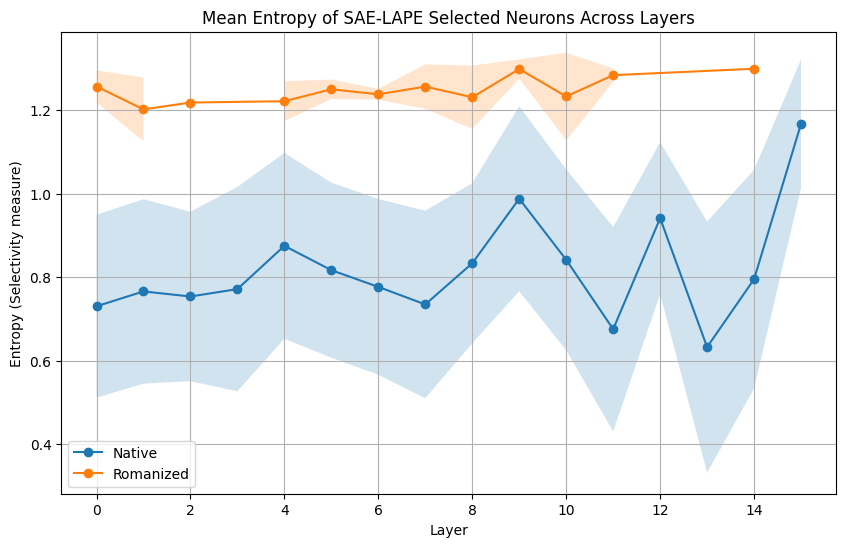

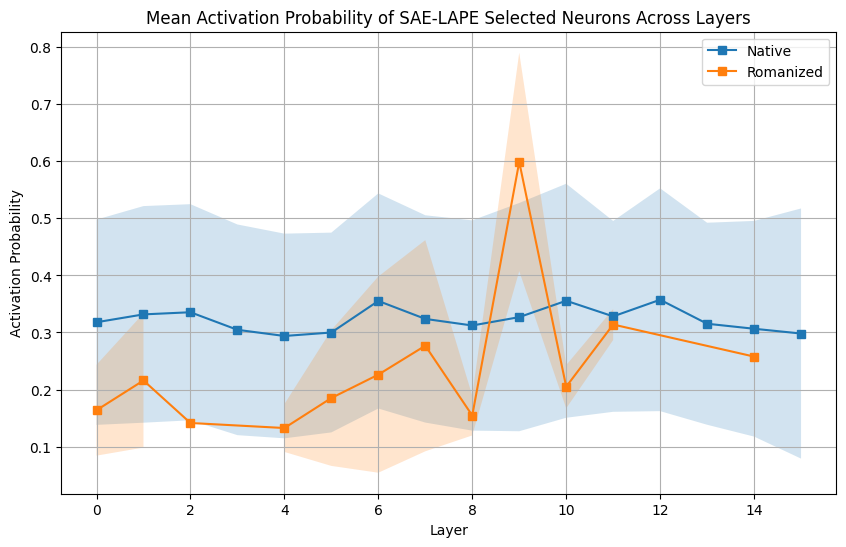

In [8]:
# --- SAE-LAPE Layerwise Trends: Entropy and Activation Probability ---

# Layerwise aggregation
df_layer_summary = (
    df_sae.groupby(["variant", "layer"])
    .agg({
        "entropy": ["mean", "std"],
        "activation_prob": ["mean", "std"]
    })
    .reset_index()
)
df_layer_summary.columns = ["variant", "layer", "entropy_mean", "entropy_std", "act_mean", "act_std"]

display(df_layer_summary.head())

# === Plot 1️⃣: Mean Entropy Across Layers ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C0", "C1"]):
    subset = df_layer_summary[df_layer_summary.variant == variant]
    plt.plot(subset.layer, subset.entropy_mean, marker='o', label=f"{variant.capitalize()}")
    plt.fill_between(
        subset.layer,
        subset.entropy_mean - subset.entropy_std,
        subset.entropy_mean + subset.entropy_std,
        alpha=0.2
    )
plt.title("Mean Entropy of SAE-LAPE Selected Neurons Across Layers")
plt.xlabel("Layer")
plt.ylabel("Entropy (Selectivity measure)")
plt.legend()
plt.grid(True)
plt.show()

# === Plot 2️⃣: Mean Activation Probability Across Layers ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C2", "C3"]):
    subset = df_layer_summary[df_layer_summary.variant == variant]
    plt.plot(subset.layer, subset.act_mean, marker='s', label=f"{variant.capitalize()}")
    plt.fill_between(
        subset.layer,
        subset.act_mean - subset.act_std,
        subset.act_mean + subset.act_std,
        alpha=0.2
    )
plt.title("Mean Activation Probability of SAE-LAPE Selected Neurons Across Layers")
plt.xlabel("Layer")
plt.ylabel("Activation Probability")
plt.legend()
plt.grid(True)
plt.show()


,variant,language,entropy_mean,entropy_std,act_mean,act_std
0,native,bn,0.726863,0.264286,0.316859,0.192722
1,native,hi,0.783336,0.195867,0.329575,0.186474
2,native,sd,0.986275,0.197499,0.332571,0.172368
3,native,ur,0.907105,0.236697,0.321890,0.180038
4,romanized,bn,1.288460,0.021392,0.355449,0.156748
5,romanized,sd,1.224877,0.061812,0.167508,0.068604
6,romanized,ur,1.235374,0.055486,0.129321,0.021567


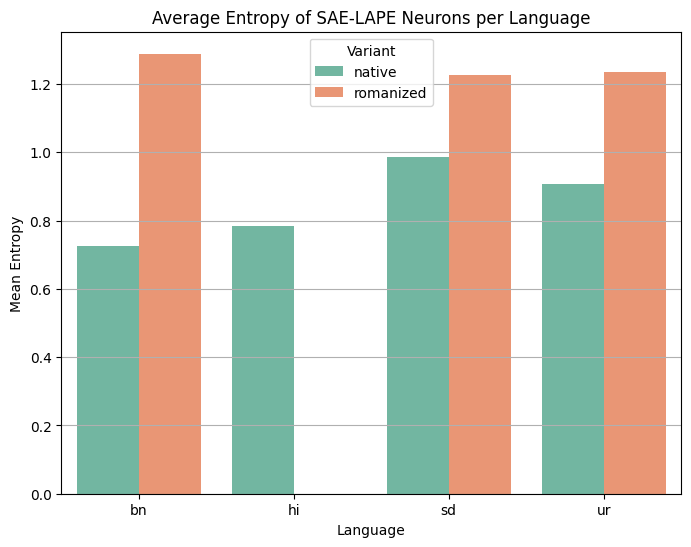

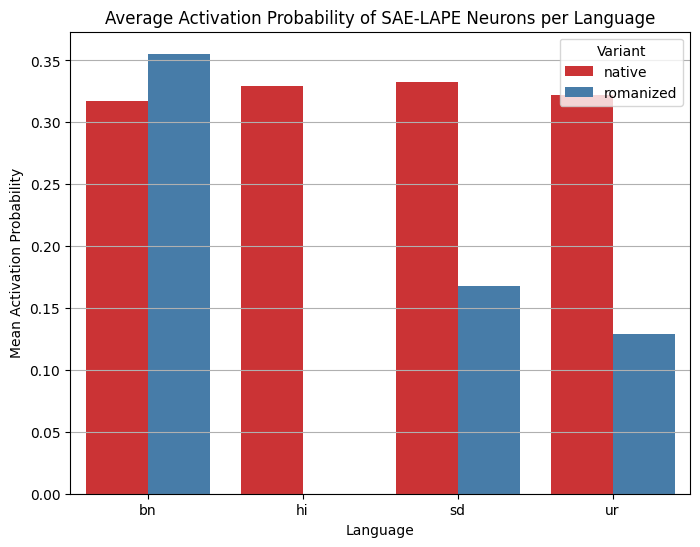

In [10]:
# --- SAE-LAPE Per-Language Analysis ---
import seaborn as sns

df_lang_summary = (
    df_sae.groupby(["variant", "language"])
    .agg({
        "entropy": ["mean", "std"],
        "activation_prob": ["mean", "std"]
    })
    .reset_index()
)
df_lang_summary.columns = ["variant", "language", "entropy_mean", "entropy_std", "act_mean", "act_std"]

display(df_lang_summary)

# === Plot: Entropy per Language ===
plt.figure(figsize=(8,6))
sns.barplot(
    x="language", y="entropy_mean", hue="variant",
    data=df_lang_summary, palette="Set2", capsize=0.2
)
plt.title("Average Entropy of SAE-LAPE Neurons per Language")
plt.ylabel("Mean Entropy")
plt.xlabel("Language")
plt.legend(title="Variant")
plt.grid(True, axis='y')
plt.show()

# === Plot: Activation Probability per Language ===
plt.figure(figsize=(8,6))
sns.barplot(
    x="language", y="act_mean", hue="variant",
    data=df_lang_summary, palette="Set1", capsize=0.2
)
plt.title("Average Activation Probability of SAE-LAPE Neurons per Language")
plt.ylabel("Mean Activation Probability")
plt.xlabel("Language")
plt.legend(title="Variant")
plt.grid(True, axis='y')
plt.show()


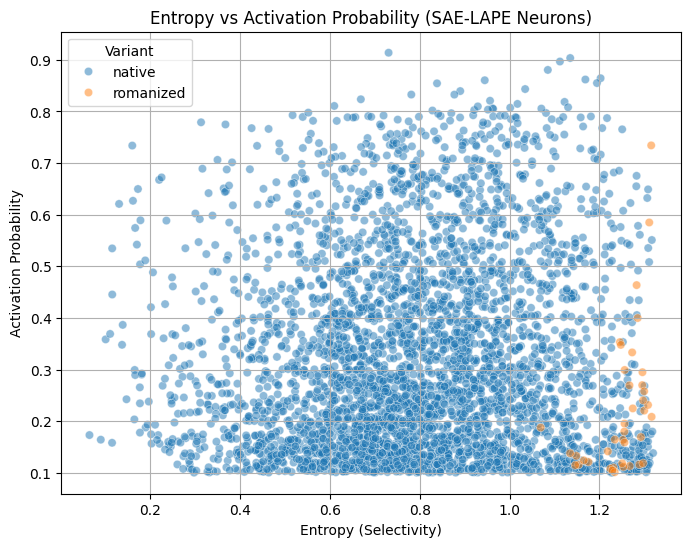

,variant,metric,correlation
0,native,entropy,0.059602
1,romanized,entropy,0.457192


In [11]:
# --- Entropy vs Activation Relationship ---

import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sae,
    x="entropy",
    y="activation_prob",
    hue="variant",
    alpha=0.5,
)
plt.title("Entropy vs Activation Probability (SAE-LAPE Neurons)")
plt.xlabel("Entropy (Selectivity)")
plt.ylabel("Activation Probability")
plt.legend(title="Variant")
plt.grid(True)
plt.show()

# Optionally, compute correlations per variant
corrs = (
    df_sae.groupby("variant")[["entropy", "activation_prob"]]
    .corr()
    .iloc[0::2,-1]
    .reset_index()
)
corrs.columns = ["variant", "metric", "correlation"]
display(corrs)


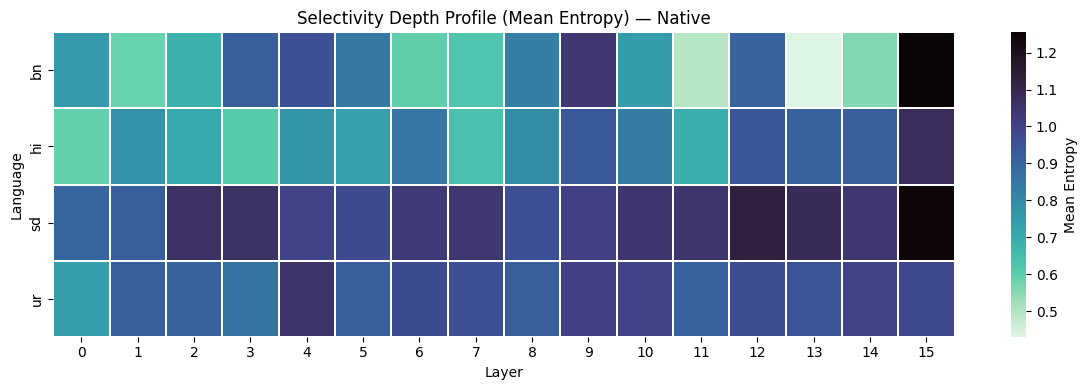

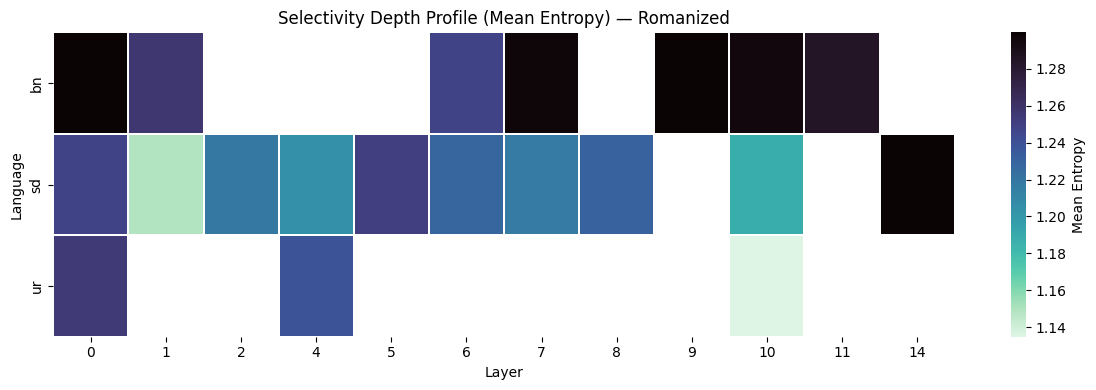

In [ ]:
# --- SAE-LAPE Selectivity Depth Profile (Entropy Heatmap) ---

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Aggregate mean entropy per layer × language × variant
df_entropy = (
    df_sae.groupby(["variant", "language", "layer"])
    .agg(entropy_mean=("entropy", "mean"))
    .reset_index()
)

# Separate heatmaps for native and romanized
for variant in ["native", "romanized"]:
    subset = df_entropy[df_entropy.variant == variant]
    pivot = subset.pivot(index="language", columns="layer", values="entropy_mean")

    plt.figure(figsize=(12, 4))
    sns.heatmap(
        pivot,
        cmap="mako_r",
        cbar_kws={'label': 'Mean Entropy'},
        vmin=pivot.min().min(),
        vmax=pivot.max().max(),
        linewidths=0.3,
        annot=False,
    )
    plt.title(f"Selectivity Depth Profile (Opp of Mean Entropy) — {variant.capitalize()}")
    plt.xlabel("Layer")
    plt.ylabel("Language")
    plt.tight_layout()
    plt.show()


,variant,layer,num_neurons
0,native,0,367
1,native,1,309
2,native,2,261
3,native,3,211
4,native,4,215


,variant,layer,language,num_neurons
0,native,0,bn,100
1,native,0,hi,100
2,native,0,sd,67
3,native,0,ur,100
4,native,1,bn,100


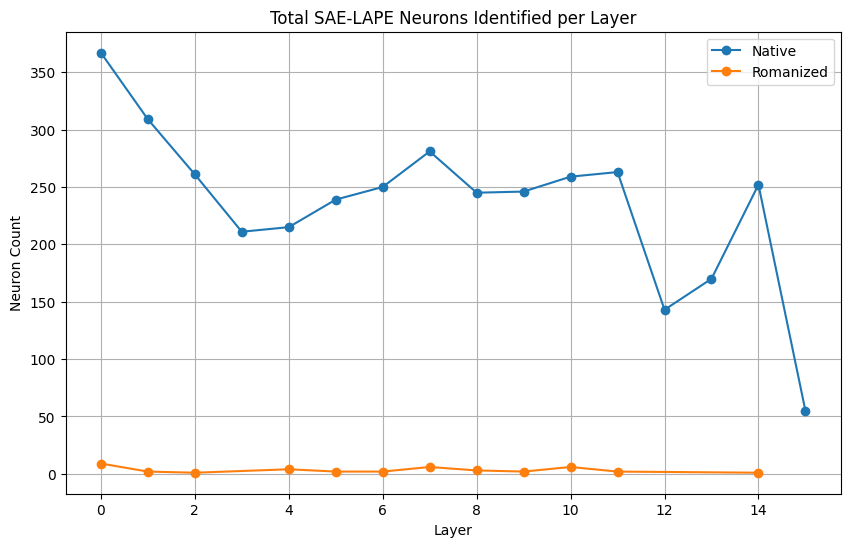

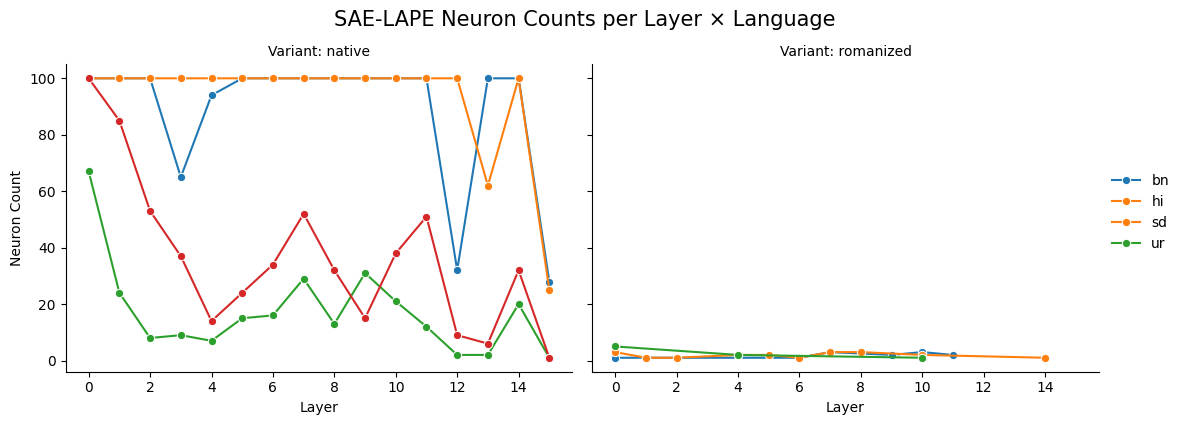

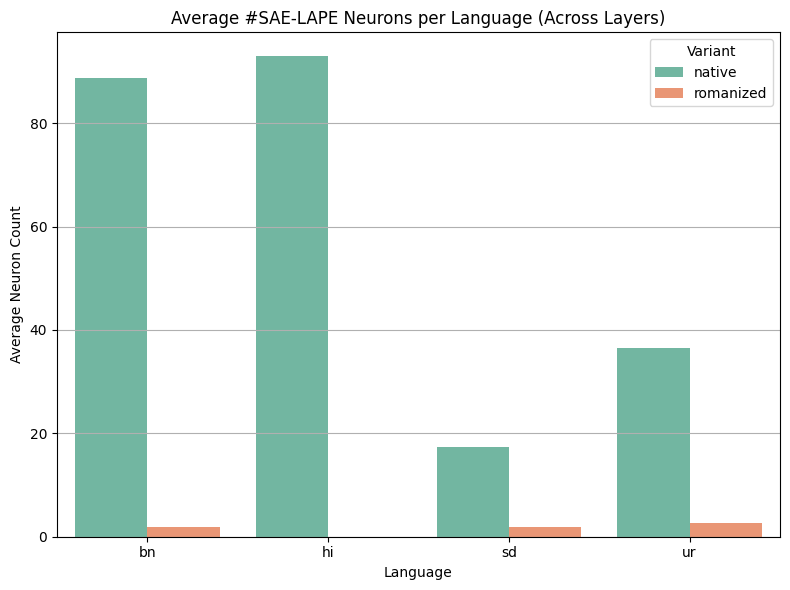

In [ ]:
# --- SAE-LAPE Neuron Counts Across Layers and Languages ---

# Overall counts per variant × layer
df_counts_layer = (
    df_sae.groupby(["variant", "layer"])
    .size()
    .reset_index(name="num_neurons")
)

# Per-language counts per layer × variant
df_counts_lang = (
    df_sae.groupby(["variant", "layer", "language"])
    .size()
    .reset_index(name="num_neurons")
)

display(df_counts_layer.head())
display(df_counts_lang.head())

# === Total neurons per layer ===
plt.figure(figsize=(10,6))
for variant, color in zip(["native", "romanized"], ["C0", "C1"]):
    subset = df_counts_layer[df_counts_layer.variant == variant]
    plt.plot(subset.layer, subset.num_neurons, marker='o', label=f"{variant.capitalize()}")
plt.title("Total SAE-LAPE Neurons Identified per Layer")
plt.xlabel("Layer")
plt.ylabel("Neuron Count")
plt.legend()
plt.grid(True)
plt.show()

# === Per-language neuron counts per layer ===
g = sns.FacetGrid(df_counts_lang, col="variant", height=4, aspect=1.4, sharey=True)
g.map_dataframe(sns.lineplot, x="layer", y="num_neurons", hue="language", marker="o")
g.add_legend()
g.set_titles("Variant: {col_name}")
g.set_axis_labels("Layer", "Neuron Count")
g.fig.suptitle("SAE-LAPE Neuron Counts per Layer × Language", fontsize=15, y=1.05)
plt.show()

# === Average neurons per language across layers ===
avg_counts = (
    df_counts_lang.groupby(["variant", "language"])["num_neurons"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))
sns.barplot(x="language", y="num_neurons", hue="variant", data=avg_counts, palette="Set2")
plt.title("Average #SAE-LAPE Neurons per Language (Across Layers)")
plt.ylabel("Average Neuron Count")
plt.xlabel("Language")
plt.legend(title="Variant")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()
